In [1]:
source('../utilities/functions/pathway-heatmaps.R')

In [2]:
pathways <- c(
  "CEBPD ENCODE",
  "CYTOKINE SIGNALING IN IMMUNE SYSTEM",
  "EPSTEIN-BARR VIRUS INFECTION",
  "HYPOXIA",
  "INTERFERON ALPHA RESPONSE",
  "INTERFERON GAMMA RESPONSE",
  "OXIDATIVE PHOSPHORYLATION",
  "TCR SIGNALING",
  "TGF-BETA SIGNALING",
  "TNF-ALPHA SIGNALING VIA NF-KB"
)

In [3]:
celltypes <- c(
  "CMP Core",
  "HSPC Multi",
  "Prog B Pre",
  "CD16 Mono Core",
  "CD14 Mono Core",
  "pDC",
  "cDC2 Core",
  "Treg",
  "Naive B Core",
  "CD8 T Naive Core",
  "CD4 T Naive Core",
  "CD4 T EM1",
  "CD8 T EM1",
  "CD56dim NK GZMK+",
  "CD56br NK",
  "Mem B Core"
)

In [4]:
# Load bone marrow data files
pretx_v_healthy <- read.csv('../../data/figure-inputs/l3-fgsea_all_results/fgsea_all_results_bmmc_PreTx_vs_Healthy.csv') %>% 
    filter(celltype %in% celltypes)
ei_v_healthy <- read.csv('../../data/figure-inputs/l3-fgsea_all_results/fgsea_all_results_bmmc_EI_vs_Healthy.csv') %>%
    filter(celltype %in% celltypes)
asct1y_v_healthy <- read.csv('../../data/figure-inputs/l3-fgsea_all_results/fgsea_all_results_bmmc_ASCT1y_vs_Healthy.csv') %>%
    filter(celltype %in% celltypes)

# Create list of datasets and comparison names
data_list <- list(pretx_v_healthy, ei_v_healthy, asct1y_v_healthy)
bm_comparison_names <- c("PreTx vs Healthy", "EI vs Healthy", "ASCT1y vs Healthy")

Filtered to 16 cell types that have data across datasets



Reordered cell types based on L3 to L1 hierarchy



Selected 10 pathways from combined data



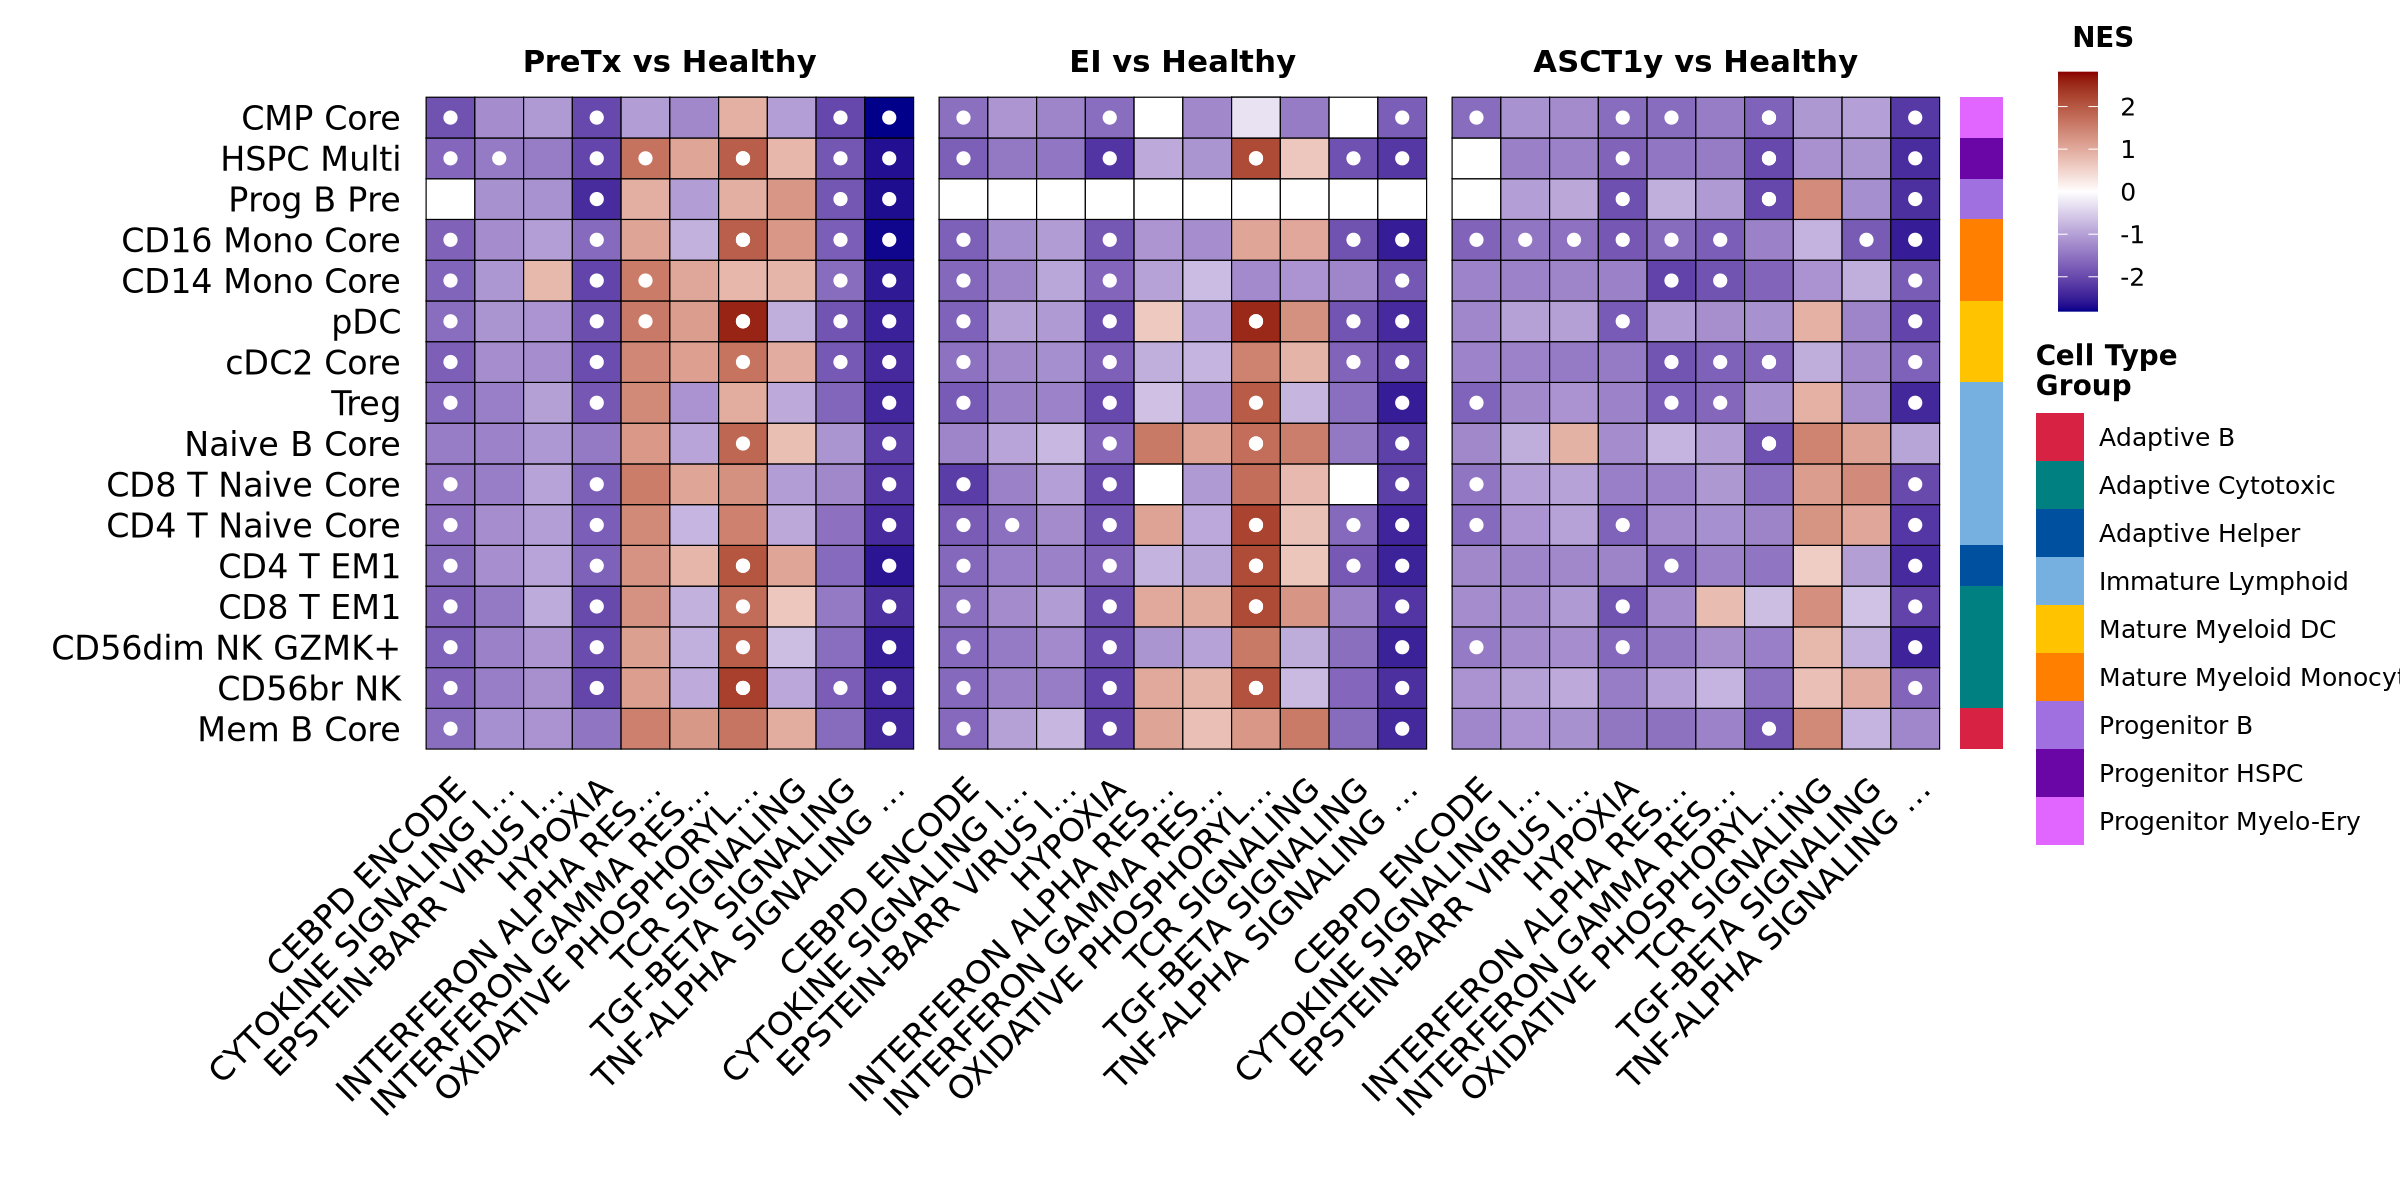

In [5]:
# Set plot dimensions
plot_width = 12
plot_height = 6
plot_dpi = 200

# Faceted heatmap
p <- create_faceted_pathway_heatmap(
  data_list = data_list,
  comparison_names = bm_comparison_names,
  pathway_method = "manual",
  celltypes = rev(celltypes),
  pathway_list = pathways,   
  max_label_length = 20,
  plot_width = plot_width,
  plot_height = plot_height,
  facet_ncol = 7
)

# Display plot
p

In [6]:
ggsave("fig_3c.pdf", plot = p, 
       width = plot_width, 
       height = plot_height, 
       dpi = plot_dpi, 
       device = cairo_pdf, 
       path = "../../data/figure-outputs/figure-3")